In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (Dense, LSTM, Bidirectional, Dropout,
                                     GlobalAveragePooling2D, Input,
                                     Concatenate, Reshape)
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

2026-03-29 08:14:02.907440: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774772043.086724      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774772043.135287      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774772043.493474      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774772043.493510      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774772043.493513      55 computation_placer.cc:177] computation placer alr

Dataset link: https://www.kaggle.com/datasets/afridirahman/brain-stroke-ct-image-dataset?select=Brain_Data_Organised

In [2]:
data = []
labels = []

dataset_path = "/kaggle/input/datasets/afridirahman/brain-stroke-ct-image-dataset/Brain_Data_Organised"

categories = ["Normal", "Stroke"]   # IMPORTANT (check folder names exactly)

for category in categories:
    path = os.path.join(dataset_path, category)
    label = 1 if category.lower() == "stroke" else 0

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)

        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (128,128))  # initial resize
            data.append(img)
            labels.append(label)
        except:
            pass

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (2501, 128, 128)
Labels shape: (2501,)


In [3]:
x_train, x_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [4]:
# Resize to 224 for ResNet
x_train = np.array([cv2.resize(img, (224,224)) for img in x_train])
x_test  = np.array([cv2.resize(img, (224,224)) for img in x_test])

# Convert grayscale → RGB
x_train = np.stack((x_train,)*3, axis=-1)
x_test  = np.stack((x_test,)*3, axis=-1)

# Normalize
x_train = x_train / 255.0
x_test  = x_test / 255.0

print("Train shape:", x_train.shape)

Train shape: (2000, 224, 224, 3)


In [5]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.8025682182985554), 1: np.float64(1.3262599469496021)}


In [6]:
input_layer = Input(shape=(224,224,3))

# CNN
base_model = ResNet50(
    weights='imagenet',   # Kaggle supports internet
    include_top=False,
    input_tensor=input_layer
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Feature extraction
x = base_model.output
x = GlobalAveragePooling2D()(x)

# -------- BiLSTM --------
lstm_input = Reshape((1, x.shape[-1]))(x)
lstm_branch = Bidirectional(LSTM(128))(lstm_input)

# -------- DNN --------
dnn_branch = Dense(256, activation='relu')(x)
dnn_branch = Dropout(0.5)(dnn_branch)
dnn_branch = Dense(128, activation='relu')(dnn_branch)

# -------- Combine --------
combined = Concatenate()([lstm_branch, dnn_branch])

z = Dense(128, activation='relu')(combined)
z = Dropout(0.5)(z)
output = Dense(1, activation='sigmoid')(z)

model11 = Model(inputs=input_layer, outputs=output)

model11.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model11.summary()

I0000 00:00:1774772083.787593      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774772083.793299      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 26,423,809 (100.80 MB)

 Trainable params: 2,836,097 (10.82 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [7]:
history = model11.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=300,
    batch_size=16,
    class_weight=class_weights 
)


Epoch 1/300


I0000 00:00:1774772101.846248     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.5094 - loss: 0.7276 - val_accuracy: 0.6068 - val_loss: 0.6726
Epoch 2/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.5340 - loss: 0.7098 - val_accuracy: 0.6128 - val_loss: 0.6798
Epoch 3/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.5187 - loss: 0.7008 - val_accuracy: 0.4631 - val_loss: 0.6954
Epoch 4/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.5391 - loss: 0.6868 - val_accuracy: 0.6427 - val_loss: 0.6766
Epoch 5/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.5115 - loss: 0.6924 - val_accuracy: 0.4890 - val_loss: 0.6963
Epoch 6/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.5343 - loss: 0.6796 - val_accuracy: 0.6567 - val_loss: 0.6586
Epoch 7/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.5813 - loss: 0.6730 - val_accuracy: 0.6687 - val_loss: 0.6382
Epoch 8/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.6024 - loss: 0.6681 - val

In [8]:
model11.save("/kaggle/working/stroke_model12.h5")

In [9]:
import os
print(os.listdir('/kaggle/working'))

['.virtual_documents', 'stroke_model12.h5']


In [10]:
import shutil

shutil.copy(
    '/kaggle/working/stroke_model12.h5',
    '/kaggle/working/final_model.h5'
)

print("Model ready for download!")

Model ready for download!


In [11]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

input_layer = Input(shape=(224,224,3))

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

# Fine-tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model123 = Model(inputs=input_layer, outputs=output)

model123.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model123.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,410,532 (16.82 MB)

 Trainable params: 1,857,121 (7.08 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

## from tensorflow.keras.applications import DenseNet121

input_layer = Input(shape=(224,224,3))

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

# Fine-tune
for layer in base_model.layers[:-40]:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model1223 = Model(inputs=input_layer, outputs=output)

model123.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
import numpy as np

# Class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

# Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]

# # Train
# history = model.fit(
#     x_train, y_train,
#     validation_data=(x_test, y_test),
#     epochs=25,
#     batch_size=16,
#     class_weight=class_weights,
#     callbacks=callbacks
# )
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

history = model123.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    validation_data=(x_test, y_test),
    epochs=100,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1774775572.618876     126 service.cc:152] XLA service 0x7988d40fed60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774775572.618976     126 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774775572.618986     126 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-03-29 09:13:01.685386: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 09:13:01.824206: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 09:13:02.144640: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.5238 - loss: 0.7099

2026-03-29 09:13:39.747015: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 09:13:39.890035: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 09:13:40.236050: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 09:13:40.376423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 09:13:41.155795: E external/local_xla/xla/stream_

125/125 ━━━━━━━━━━━━━━━━━━━━ 75s 342ms/step - accuracy: 0.5239 - loss: 0.7099 - val_accuracy: 0.6088 - val_loss: 0.6807
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.5113 - loss: 0.7107 - val_accuracy: 0.6088 - val_loss: 0.6821
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.5121 - loss: 0.7049 - val_accuracy: 0.6088 - val_loss: 0.6820
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.4894 - loss: 0.7122 - val_accuracy: 0.6128 - val_loss: 0.6881
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - accuracy: 0.5305 - loss: 0.7038 - val_accuracy: 0.4930 - val_loss: 0.6928
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.5169 - loss: 0.7024 - val_accuracy: 0.4890 - val_loss: 0.6957
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.4926 - loss: 0.7058 - val_accuracy: 0.4770 - val_loss: 0.6944
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - accuracy: 0.4842 - loss: 0.703

In [13]:
import numpy as np

print("Class distribution:", np.bincount(labels))

Class distribution: [1551  950]


In [14]:
model123.save("stroke_model.h5")

In [17]:
loss, acc = model11.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.9030 - loss: 0.3140
Test Accuracy: 0.8982036113739014


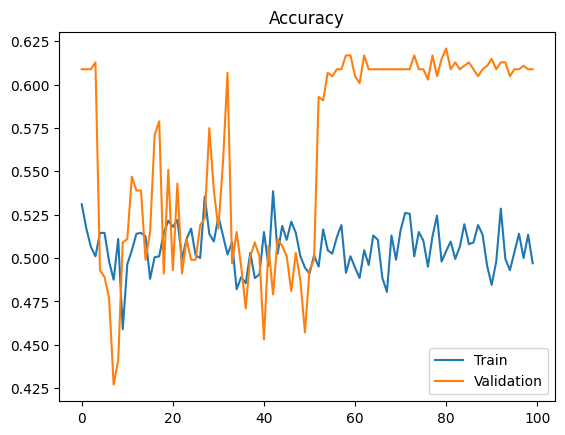

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [22]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model123.predict(img)

    if pred[0][0] > 0.5:
        print("🧠 Stroke Detected")
    else:
        print("✅ Normal Brain")
predict_image('/kaggle/input/datasets/afridirahman/brain-stroke-ct-image-dataset/Brain_Data_Organised/Stroke/58 (1).jpg')

2026-03-29 09:47:55.993016: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 09:47:56.128433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 09:47:56.875285: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-29 09:47:57.010690: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
✅ Normal Brain
